# AIM: predict whether a telecom customer will churn (cancel subscription) or not 

## AIM: The main objective of this project is to predict whether a telecom customer will churn (cancel subscription) or not using machine learning models and Reduce churn rate (currently >10%) by identifying high-risk customers and enabling proactive retention strategies.

In [1]:
#pip install pandas sqlalchemy pymysql

In [2]:
import numpy as np # importing libraries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
#You connected to a MySQL database using:
#Username
#Password (encoded for security)
#Host
#Database name

from sqlalchemy import create_engine 
import urllib.parse

# 1. Credential
user = "dm_team3"
# The raw password with special characters
raw_password = "DM!$!Team!27@9!20&" 
host = "18.136.157.135"
db_name = "project_telecom"

# 2. URL-encode the password to handle the '!' and '@' symbols
safe_password = urllib.parse.quote_plus(raw_password)

# 3. Create the connection engine
# The password is now safely encoded in the string
connection_string = f"mysql+pymysql://{user}:{safe_password}@{host}/{db_name}"
engine = create_engine(connection_string)

# 4. Test the connection and select the data
try:
    query = "SELECT * FROM telecom_churn_data"
    df = pd.read_sql(query, engine)
    print("Connection Successful! Here is a preview of the data:")
    print(df.head())
except Exception as e:
    print(f"Still having trouble: {e}")

Connection Successful! Here is a preview of the data:
   customer_id telecom_partner gender  age              state     city  \
0            1    Reliance Jio      F   25          Karnataka  Kolkata   
1            2    Reliance Jio      F   55            Mizoram   Mumbai   
2            3        Vodafone      F   57  Arunachal Pradesh    Delhi   
3            4            BSNL      M   46         Tamil Nadu  Kolkata   
4            5            BSNL      F   26            Tripura    Delhi   

   pincode date_of_registration  num_dependents  estimated_salary  calls_made  \
0   755597           2020-01-01               4            124962          44   
1   125926           2020-01-01               2            130556          62   
2   423976           2020-01-01               0            148828          49   
3   522841           2020-01-01               1             38722          80   
4   740247           2020-01-01               2             55098          78   

   sms_sent  d

In [4]:
# Above step done to extract the telecom data into a Pandas DataFrame.

In [5]:
df.to_csv('churn_telecom_data.csv') # saving dataeset into the system


In [6]:
df=pd.read_csv(r"C:\Users\rohit\Desktop\Datamites Data\No Churn telecom\churn_telecom_data.csv") #loading the dataset

In [7]:
df.head()

,Unnamed: 0,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [8]:
df.isnull().sum() # checking null values

Unnamed: 0              0
customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

In [9]:
df.info() # checking columns and datatypes, Identify null values,Decide if cleaning is required

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Unnamed: 0            243553 non-null  int64 
 1   customer_id           243553 non-null  int64 
 2   telecom_partner       243553 non-null  object
 3   gender                243553 non-null  object
 4   age                   243553 non-null  int64 
 5   state                 243553 non-null  object
 6   city                  243553 non-null  object
 7   pincode               243553 non-null  int64 
 8   date_of_registration  243553 non-null  object
 9   num_dependents        243553 non-null  int64 
 10  estimated_salary      243553 non-null  int64 
 11  calls_made            243553 non-null  int64 
 12  sms_sent              243553 non-null  int64 
 13  data_used             243553 non-null  int64 
 14  churn                 243553 non-null  int64 
dtypes: int64(10), obj

In [10]:
df['date_of_registration']=pd.to_datetime(df['date_of_registration']) #Converting string dates to datetime format for calculations.

In [11]:
reference_date=df['date_of_registration'].max()
reference_date

Timestamp('2023-05-04 00:00:00')

In [12]:
df['tenure_months'] = ((reference_date - df['date_of_registration']).dt.days / 30).astype(int) #Creating tenure Feature to find the number of months the customer has stayed with the telecom company.
df['tenure_months'].unique()

array([40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24,
       23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,  7,
        6,  5,  4,  3,  2,  1,  0])

In [13]:
df['estimated_salary_in_k']=(df['estimated_salary']/1000).round() #Simplified salary values to make data easier to interpret

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Unnamed: 0             243553 non-null  int64         
 1   customer_id            243553 non-null  int64         
 2   telecom_partner        243553 non-null  object        
 3   gender                 243553 non-null  object        
 4   age                    243553 non-null  int64         
 5   state                  243553 non-null  object        
 6   city                   243553 non-null  object        
 7   pincode                243553 non-null  int64         
 8   date_of_registration   243553 non-null  datetime64[ns]
 9   num_dependents         243553 non-null  int64         
 10  estimated_salary       243553 non-null  int64         
 11  calls_made             243553 non-null  int64         
 12  sms_sent               243553 non-null  int6

In [15]:
df.describe() # checking various parameter to find detailed insight of dataset for numerical columns

,Unnamed: 0,customer_id,age,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,tenure_months,estimated_salary_in_k
count,243553.000000,243553.000000,243553.000000,243553.000000,243553,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121776.000000,121777.000000,46.077609,549501.270541,2021-09-01 00:00:00.354748416,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478,19.852340,85.020509
min,0.000000,1.000000,18.000000,100006.000000,2020-01-01 00:00:00,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000,0.000000,20.000000
25%,60888.000000,60889.000000,32.000000,324586.000000,2020-10-31 00:00:00,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000,10.000000,53.000000
50%,121776.000000,121777.000000,46.000000,548112.000000,2021-09-01 00:00:00,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000,20.000000,85.000000
75%,182664.000000,182665.000000,60.000000,774994.000000,2022-07-03 00:00:00,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000,30.000000,117.000000
max,243552.000000,243553.000000,74.000000,999987.000000,2023-05-04 00:00:00,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000,40.000000,150.000000
std,70307.839393,70307.839393,16.444029,259808.860574,NaN,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359,11.731729,37.511098


In [16]:
df.describe(include='object') # checking various parameter to find detailed insight of dataset for non-numerical columns

,telecom_partner,gender,state,city
count,243553,243553,243553,243553
unique,4,2,28,6
top,Reliance Jio,M,Uttarakhand,Chennai
freq,61123,145977,8856,40749


In [17]:
df['telecom_partner'].value_counts() # checking unique values with their counts.

telecom_partner
Reliance Jio    61123
Airtel          60905
Vodafone        60802
BSNL            60723
Name: count, dtype: int64

In [18]:
df['gender'].value_counts() # checking unique values with their counts.

gender
M    145977
F     97576
Name: count, dtype: int64

In [19]:
df['city'].value_counts() # checking unique values with their counts.

city
Chennai      40749
Hyderabad    40698
Kolkata      40661
Bangalore    40603
Delhi        40456
Mumbai       40386
Name: count, dtype: int64

In [20]:
df[df.duplicated()] # checking duplicate values to find them and delete

,Unnamed: 0,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,tenure_months,estimated_salary_in_k


In [21]:
df.head()

,Unnamed: 0,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,tenure_months,estimated_salary_in_k
0,0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0,40,125.0
1,1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0,40,131.0
2,2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1,40,149.0
3,3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1,40,39.0
4,4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0,40,55.0


In [22]:
df['data_used'] = df['data_used'].apply(lambda x: x if x >= 0 else 0) #Data cleaning done to find negative Values as negative usage is unrealistic so replaced it with 0.

In [23]:
df['calls_made'] = df['calls_made'].apply(lambda x: x if x >= 0 else 0) #Data cleaning done to find negative Values as negative usage is unrealistic so replaced it with 0.

In [24]:
df['sms_sent'] = df['sms_sent'].apply(lambda x: x if x >= 0 else 0) #Data cleaning done to find negative Values as negative usage is unrealistic so replaced it with 0.

In [25]:
df['data_used'].unique()

array([    0,  5973,   193, ..., 10985, 10881, 10939])

In [26]:
df1=df[['age','num_dependents','estimated_salary_in_k','calls_made','sms_sent','data_used']] # new dataset created to visualize if any outlier present in the dataset so we can remove them 
df1.head(2)

,age,num_dependents,estimated_salary_in_k,calls_made,sms_sent,data_used
0,25,4,125.0,44,45,0
1,55,2,131.0,62,39,5973


In [27]:
for col in df1.describe().columns: # checking unique values in each columns
    print(col)
    print(df1[col].unique())
    print('-'*50)

age
[25 55 57 46 26 36 60 53 44 56 64 70 38 22 61 59 47 58 66 71 48 20 29 73
 31 62 52 69 33 42 40 30 35 28 49 43 18 72 39 50 34 24 74 32 68 27 65 23
 37 63 19 21 67 51 41 45 54]
--------------------------------------------------
num_dependents
[4 2 0 1 3]
--------------------------------------------------
estimated_salary_in_k
[125. 131. 149.  39.  55.  73. 110. 105.  79. 126. 133. 135. 137. 140.
 148. 100.  60. 102. 138. 119.  64.  65. 115.  95.  51. 104.  61.  86.
 106.  91.  40.  69.  87.  72. 120.  46. 132.  76. 146.  48.  88.  26.
  22.  54.  89.  38. 139. 122.  34.  84. 101.  63.  98. 128. 147.  44.
 114.  47.  92. 111. 123.  71. 118.  31.  21.  24.  30. 145. 108. 144.
  96. 103.  82.  29.  59.  94.  53. 107.  23.  66.  93.  97.  33.  35.
  56.  57.  25. 134.  43.  27. 127. 113.  37.  99. 129.  80.  62.  45.
  58.  41.  28.  70. 143.  77.  75.  78. 116.  85.  68.  81. 136. 130.
 121.  74.  32. 142.  50. 124. 109.  42. 112. 117.  67.  36.  83.  49.
  20. 150.  90. 141.  52.]
----

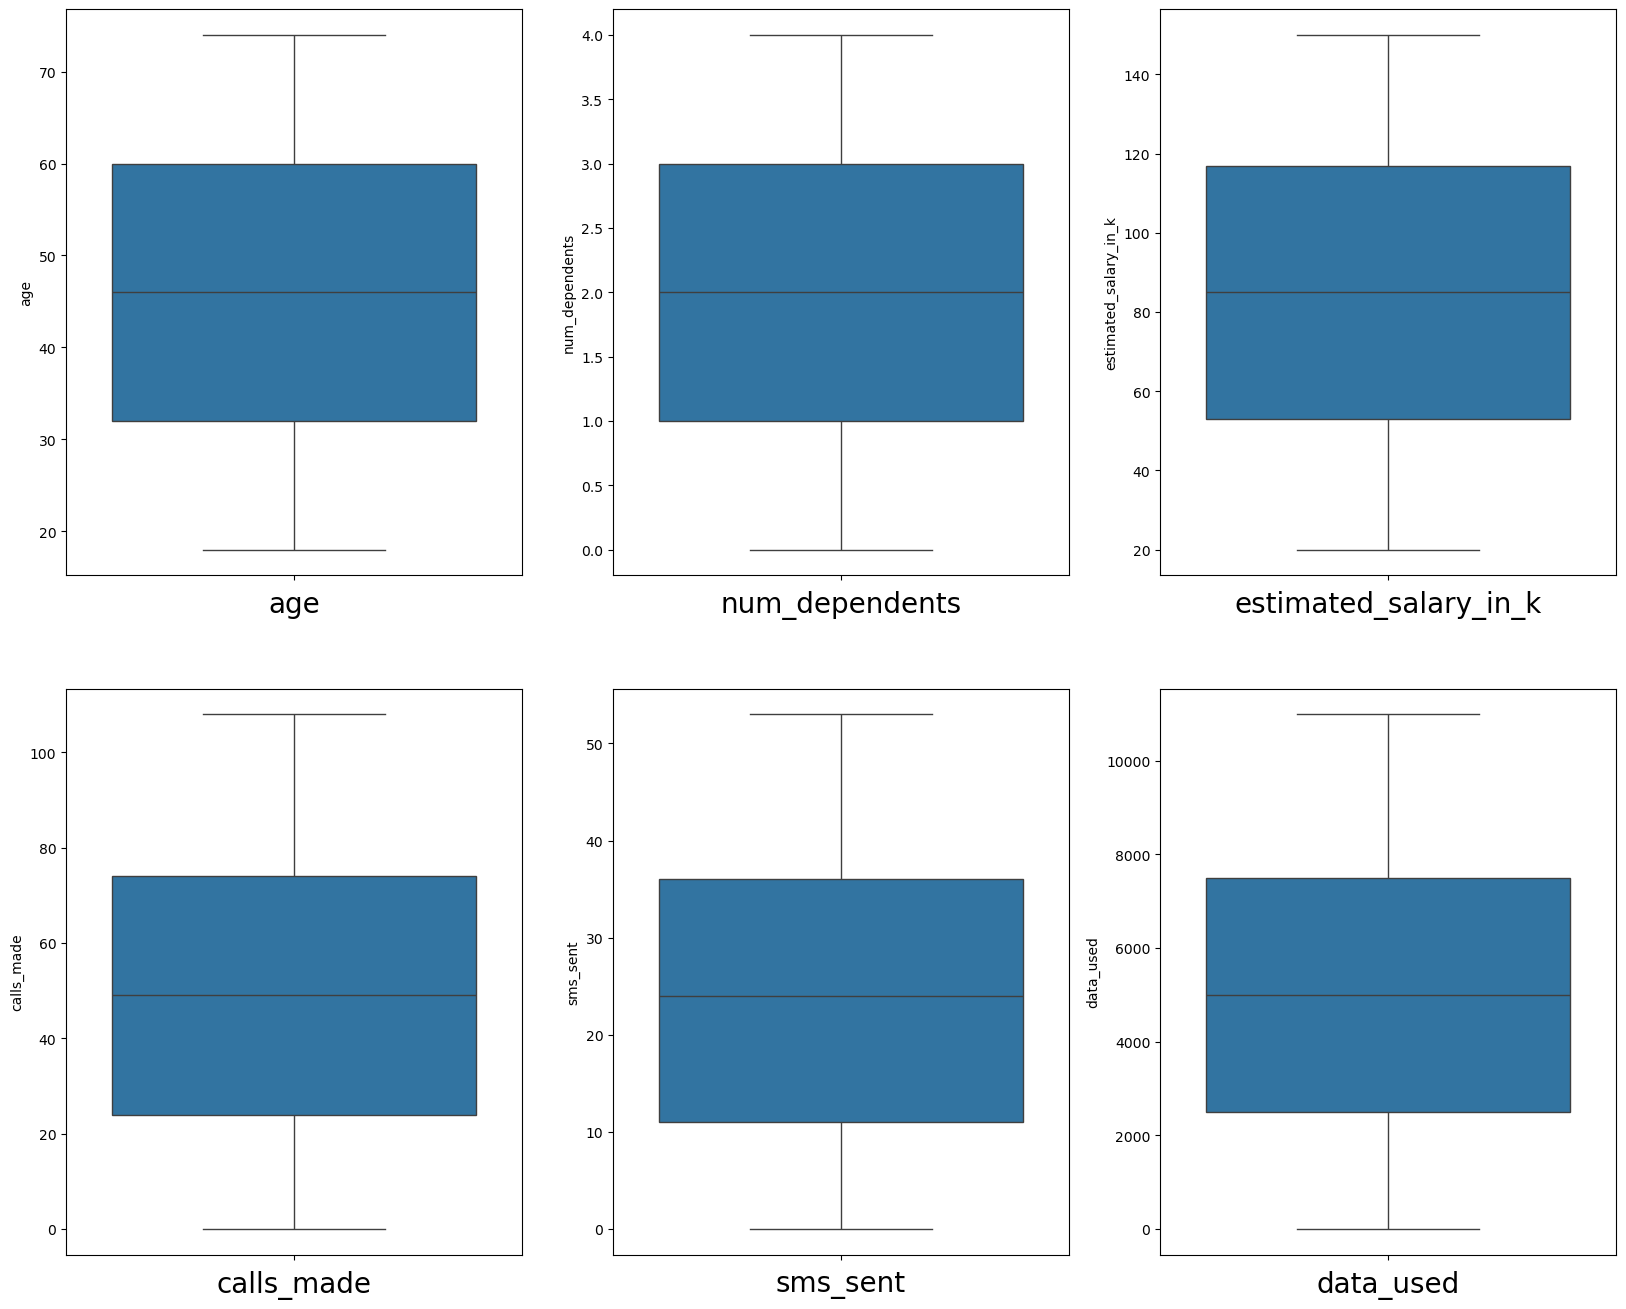

In [28]:
plt.figure(figsize=(20,25), facecolor='white') ## Visualizing each columns using boxplot to detect the outlier and remove it.
plotnumber = 1

for column in df1:
    if plotnumber<=6:     # as there are 9 columns in the data
        ax = plt.subplot(3,3,plotnumber)
        sns.boxplot(df1[column])
        plt.xlabel(column,fontsize=20)
        #plt.ylabel('Salary',fontsize=20)
    plotnumber+=1
plt.show()

In [29]:
df['data_used_in_gb']=(df['data_used']/1024).round() #Simplified data usage values to make data easier to interpret

In [30]:
df.head()

,Unnamed: 0,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,tenure_months,estimated_salary_in_k,data_used_in_gb
0,0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,0,0,40,125.0,0.0
1,1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0,40,131.0,6.0
2,2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1,40,149.0,0.0
3,3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1,40,39.0,9.0
4,4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0,40,55.0,1.0


<Axes: xlabel='estimated_salary_in_k', ylabel='count'>

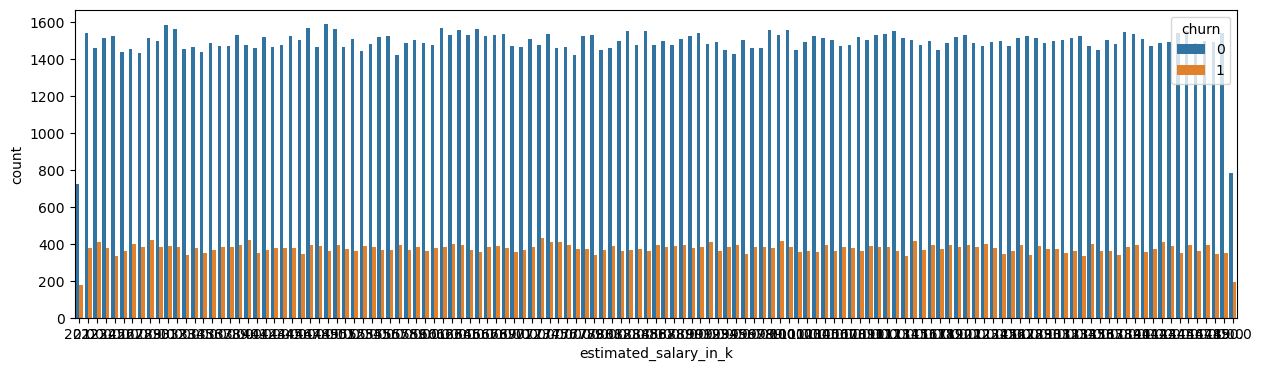

In [31]:
plt.figure(figsize=(15,4)) # Visualizing the relationship between estimated salary and its relationship with churn rate shows Lower salary customers churn more.
sns.countplot(x=df['estimated_salary_in_k'],data=df,hue=df['churn'])

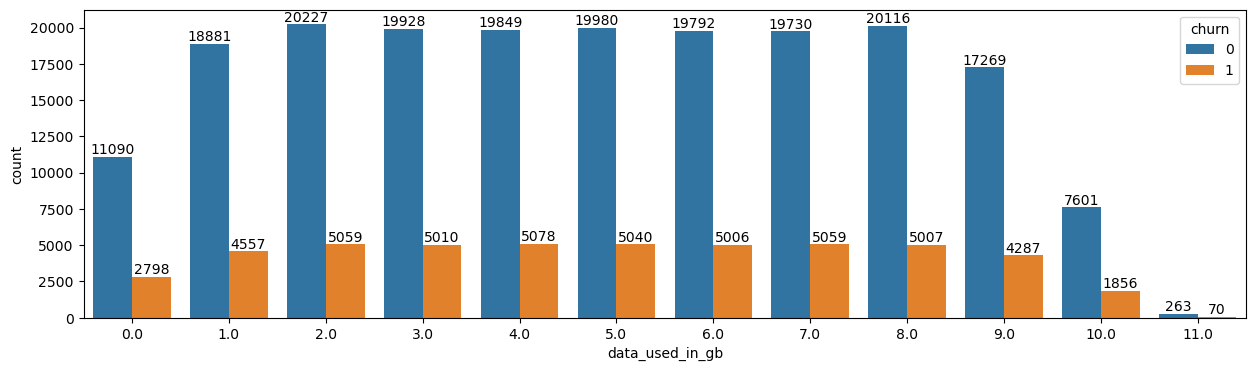

In [32]:
plt.figure(figsize=(15,4)) # Visualizing the relationship between data usage and its relationship with churn rate shows Low data usage customers churn more.
axd=sns.countplot(x=df['data_used_in_gb'],data=df,hue=df['churn'])
for bars in axd.containers:
    axd.bar_label(bars)


<Axes: xlabel='calls_made', ylabel='count'>

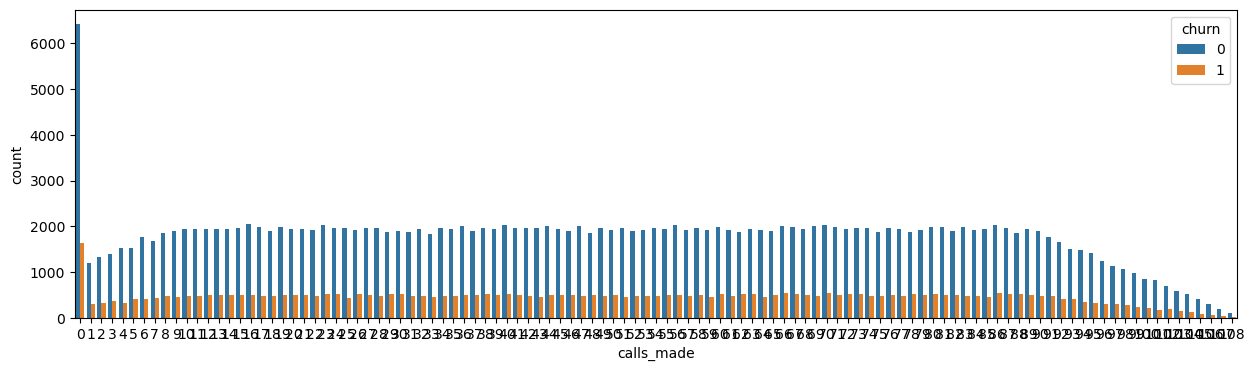

In [33]:
plt.figure(figsize=(15,4))  # Visualizing the relationship between calls made and its relationship with churn rate shows customers with fewer calls churn more
sns.countplot(x=df['calls_made'],data=df,hue=df['churn'])

<Axes: xlabel='sms_sent', ylabel='count'>

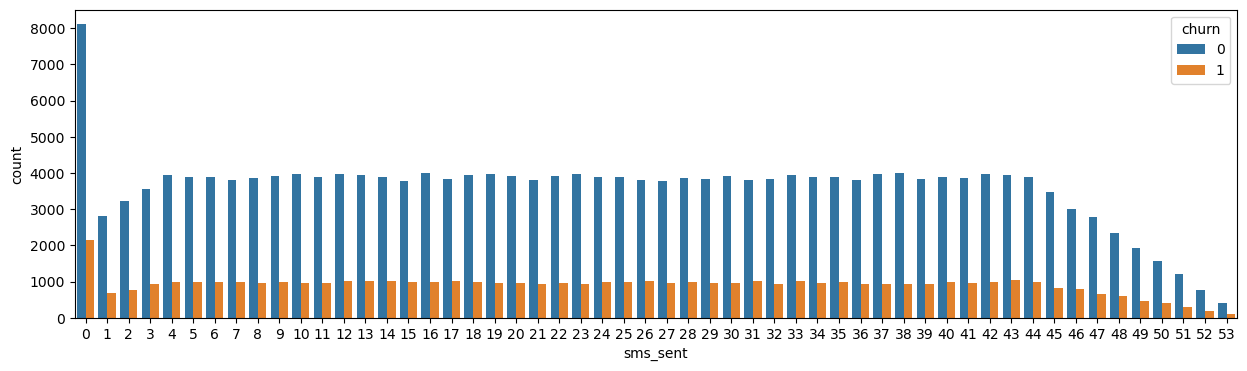

In [34]:
plt.figure(figsize=(15,4))  # Visualizing the relationship between sms sent and its relationship with churn rate. 
sns.countplot(x=df['sms_sent'],data=df,hue=df['churn'])

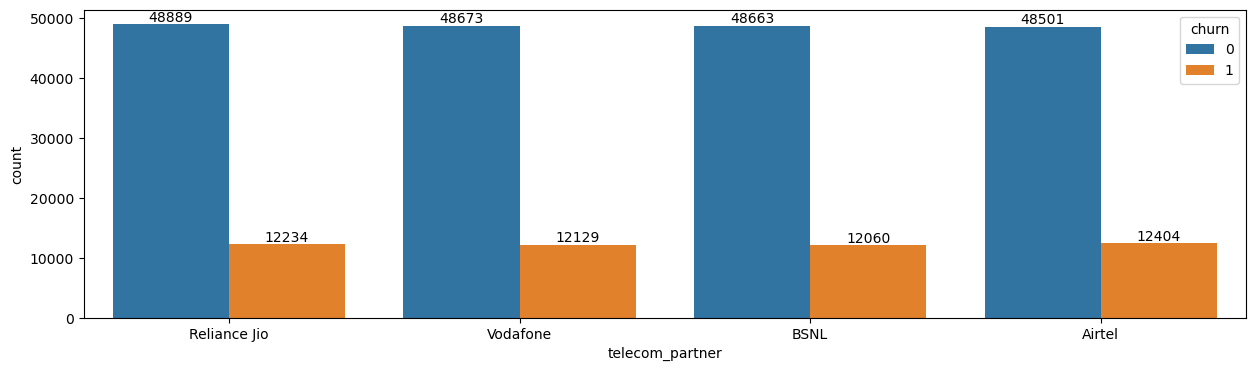

In [35]:
plt.figure(figsize=(15,4)) # Visualizing the relationship between telecom_partner and its relationship with churn rate shows it has ngeligible impact on churn rate.
axt=sns.countplot(x=df['telecom_partner'],data=df,hue=df['churn'])
for bars in axt.containers:
     axt.bar_label(bars)

<Axes: xlabel='tenure_months', ylabel='count'>

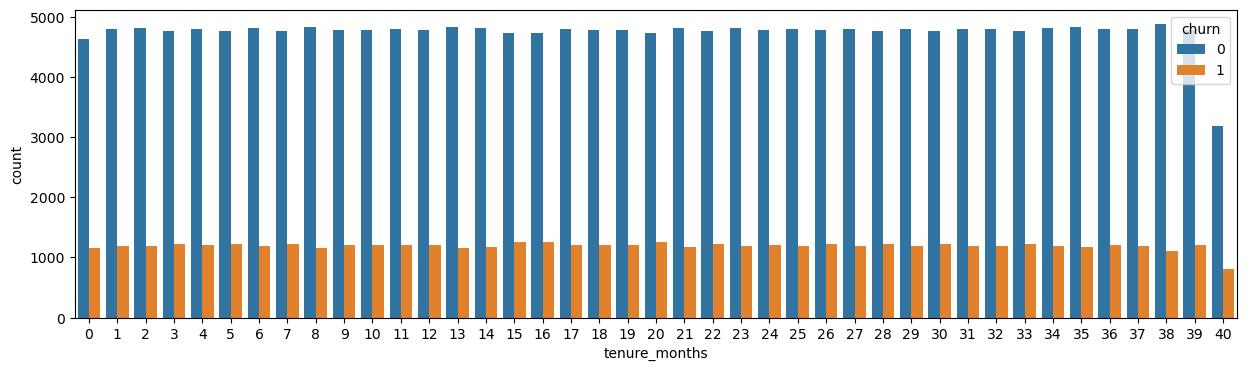

In [36]:
plt.figure(figsize=(15,4))  #Visualizing the relationship between tenure_months and its relationship with churn rate shows Customers with low tenure have higher churn while Long-term customers are more loyal.
sns.countplot(x=df['tenure_months'],data=df,hue=df['churn'])

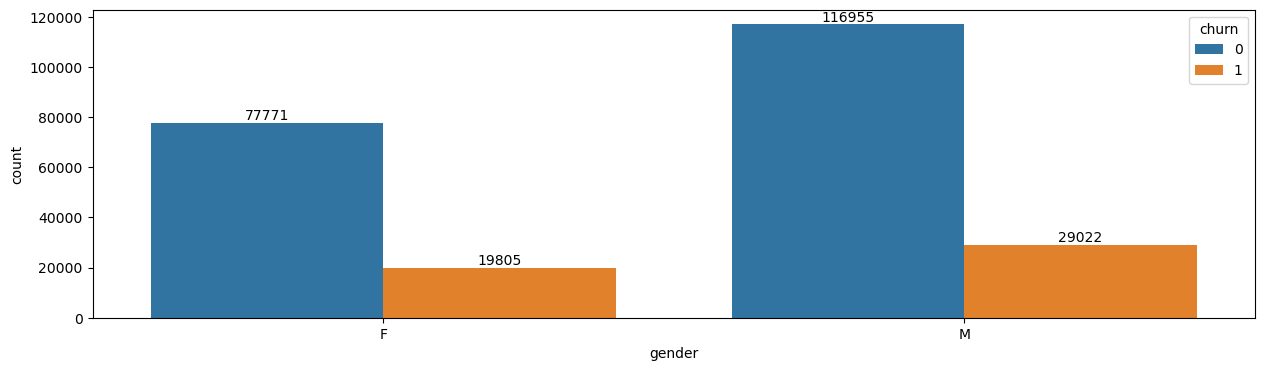

In [37]:
plt.figure(figsize=(15,4)) #Visualizing the relationship between gender and its relationship with churn rate shows it has ngeligible impact on churn rate.
axg=sns.countplot(x=df['gender'],data=df,hue=df['churn'])
for bars in axg.containers:
    axg.bar_label(bars)

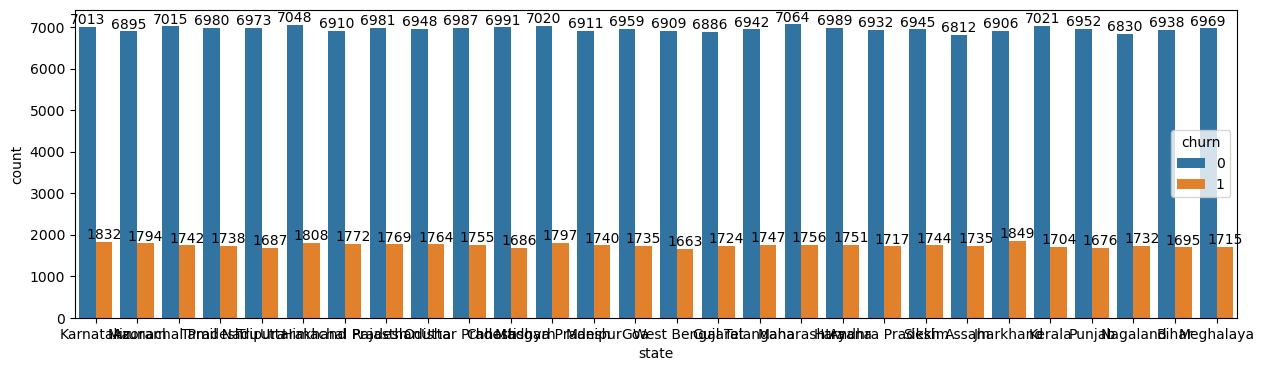

In [38]:
plt.figure(figsize=(15,4)) #Visualizing the relationship between state and its relationship with churn rate shows it has ngeligible impact on churn rate.
axs=sns.countplot(x=df['state'],data=df,hue=df['churn'])
for bars in axs.containers:
    axs.bar_label(bars)

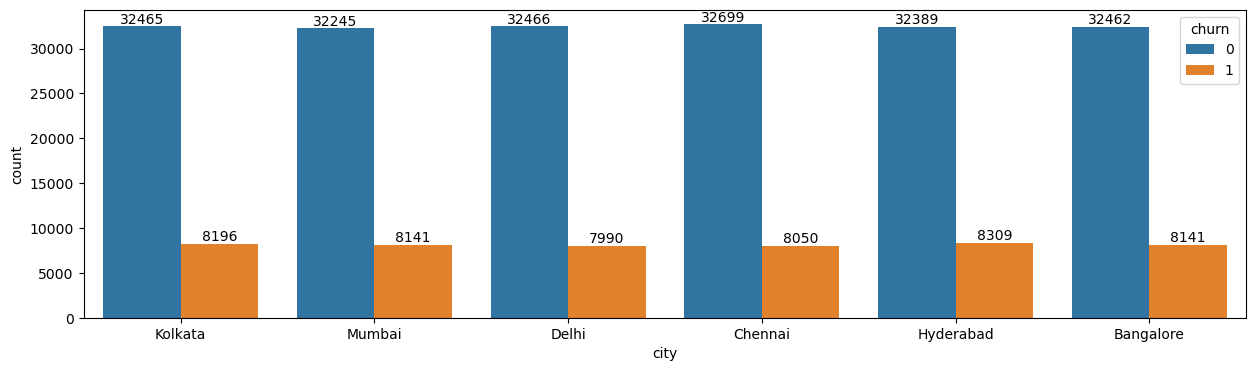

In [39]:
plt.figure(figsize=(15,4)) #Visualizing the relationship between city and its relationship with churn rate shows it has ngeligible impact on churn rate.
axc=sns.countplot(x=df['city'],data=df,hue=df['churn'])
for bars in axc.containers:
    axc.bar_label(bars)

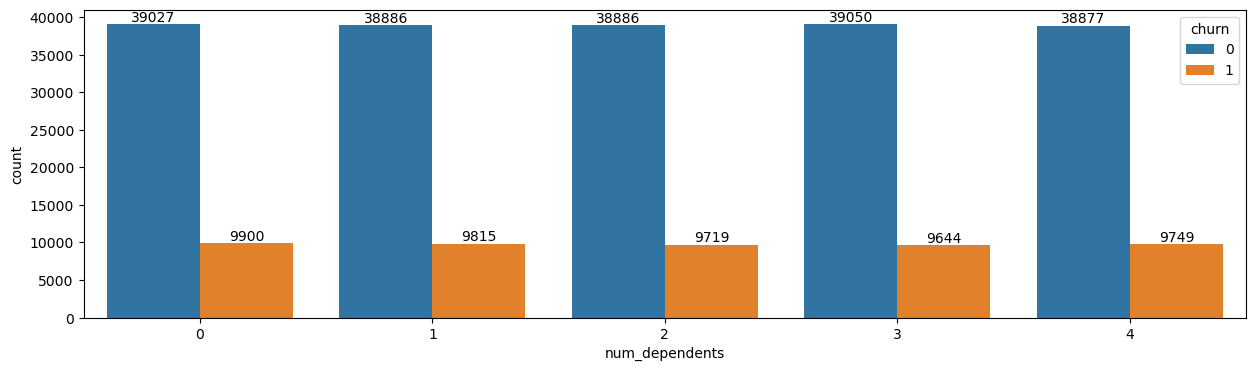

In [40]:
plt.figure(figsize=(15,4)) #Visualizing the relationship between num of dependents and its relationship with churn rate shows it has ngeligible impact on churn rate.
axd=sns.countplot(x=df['num_dependents'],data=df,hue=df['churn'])
for bars in axd.containers:
    axd.bar_label(bars)

In [41]:
genders=pd.get_dummies(df['gender']) #Encoding Categorical Variables as Machine learning models require numerical input.
tcp=pd.get_dummies(df['telecom_partner'])
cities=pd.get_dummies(df['city'])


In [42]:
df=pd.concat([df,genders],axis=1) #the One_hot_encoded columns are concatenated with the original dataeset.
df=pd.concat([df,tcp],axis=1)
df=pd.concat([df,cities],axis=1)
df.head()

,Unnamed: 0,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,...,Airtel,BSNL,Reliance Jio,Vodafone,Bangalore,Chennai,Delhi,Hyderabad,Kolkata,Mumbai
0,0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,...,False,False,True,False,False,False,False,False,True,False
1,1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,...,False,False,True,False,False,False,False,False,False,True
2,2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,...,False,False,False,True,False,False,True,False,False,False
3,3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,...,False,True,False,False,False,False,False,False,True,False
4,4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,...,False,True,False,False,False,False,True,False,False,False


In [43]:
df.columns

Index(['Unnamed: 0', 'customer_id', 'telecom_partner', 'gender', 'age',
       'state', 'city', 'pincode', 'date_of_registration', 'num_dependents',
       'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'churn',
       'tenure_months', 'estimated_salary_in_k', 'data_used_in_gb', 'F', 'M',
       'Airtel', 'BSNL', 'Reliance Jio', 'Vodafone', 'Bangalore', 'Chennai',
       'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai'],
      dtype='object')

In [44]:
#Dropping Unnecessary Columns to Avoid redundancy, Remove irrelevant features, Prevent multicollinearity.
df2=df.drop(['Unnamed: 0','customer_id','telecom_partner','gender','state','city','pincode','date_of_registration','estimated_salary','data_used','F','Reliance Jio','Bangalore'],axis=1)
df2.head(2) #Dropping Unnecessary Columns to Avoid redundancy, Remove irrelevant features, Prevent multicollinearity.

,age,num_dependents,calls_made,sms_sent,churn,tenure_months,estimated_salary_in_k,data_used_in_gb,M,Airtel,BSNL,Vodafone,Chennai,Delhi,Hyderabad,Kolkata,Mumbai
0,25,4,44,45,0,40,125.0,0.0,False,False,False,False,False,False,False,True,False
1,55,2,62,39,0,40,131.0,6.0,False,False,False,False,False,False,False,False,True


## Data cleaning and visualization completed

In [45]:
x=df2.drop(['churn'],axis=1) # making data ready as input and output for machine learning evaluation

In [46]:
y=df2[['churn']]

In [47]:
# importing various models to  check the score of each model and find the best suited for prediction.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score


In [48]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y) # using train_test_split model to split the data for model evaluation.

In [49]:
len(y_test)

48711

In [50]:
gb=GradientBoostingClassifier() # GradientBoostingClassifier model is trained and checked its various parameter and score to find best model for prediction.
gb.fit(x_train,y_train)
gb.score(x_test,y_test)
gby_pred=gb.predict(x_test)

print("model Score:", gb.score(x_test,y_test))
print('accuracy_score_is',accuracy_score(y_test,gby_pred))
print('recall_score_is',recall_score(y_test,gby_pred))
print('roc_auc_score_is',roc_auc_score(y_test,gby_pred))
print('precision_score_is',precision_score(y_test,gby_pred))
print('f1_score_is',f1_score(y_test,gby_pred))
print('cross_val_score',cross_val_score(GradientBoostingClassifier(),x,y,cv=5).mean())
print('classification_report_is',classification_report(y_test,gby_pred))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


model Score: 0.7995319332388988
accuracy_score_is 0.7995319332388988
recall_score_is 0.0
roc_auc_score_is 0.5
precision_score_is 0.0
f1_score_is 0.0


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array wa

cross_val_score 0.7995179694756231
classification_report_is               precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
dt=DecisionTreeClassifier()  # DecisionTreeClassifier model is trained and checked its various parameter and score to find best model for prediction.
dt.fit(x_train,y_train)
dt.score(x_test,y_test)
dty_pred=dt.predict(x_test)

print("model Score:", dt.score(x_test,y_test))
print('accuracy_score_is',accuracy_score(y_test,dty_pred))
print('recall_score_is',recall_score(y_test,dty_pred))
print('roc_auc_score_is',roc_auc_score(y_test,dty_pred))
print('precision_score_is',precision_score(y_test,dty_pred))
print('f1_score_is',f1_score(y_test,dty_pred))
print('cross_val_score',cross_val_score(DecisionTreeClassifier(),x,y,cv=5).mean())
print('classification_report_is',classification_report(y_test,dty_pred))

model Score: 0.6619859990556548
accuracy_score_is 0.6619859990556548
recall_score_is 0.2259088581669227
roc_auc_score_is 0.4986166280255864
precision_score_is 0.19852411807055437
f1_score_is 0.21133304593571872
cross_val_score 0.6613960146318761
classification_report_is               precision    recall  f1-score   support

           0       0.80      0.77      0.78     38946
           1       0.20      0.23      0.21      9765

    accuracy                           0.66     48711
   macro avg       0.50      0.50      0.50     48711
weighted avg       0.68      0.66      0.67     48711



In [52]:
lr=LogisticRegression() # LogisticRegression model is trained and checked its various parameter and score to find best model for prediction.
lr.fit(x_train,y_train)
lr.score(x_test,y_test)
lry_pred=lr.predict(x_test)

print("model Score:", lr.score(x_test,y_test))
print('accuracy_score_is',accuracy_score(y_test,lry_pred))
print('recall_score_is',recall_score(y_test,lry_pred))
print('roc_auc_score_is',roc_auc_score(y_test,lry_pred))
print('precision_score_is',precision_score(y_test,lry_pred))
print('f1_score_is',f1_score(y_test,lry_pred))
print('cross_val_score',cross_val_score(LogisticRegression(),x,y,cv=5).mean())
print('classification_report_is',classification_report(y_test,lry_pred))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to cont

model Score: 0.7995319332388988
accuracy_score_is 0.7995319332388988
recall_score_is 0.0
roc_auc_score_is 0.5
precision_score_is 0.0
f1_score_is 0.0


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example us

cross_val_score 0.7995220753244048
classification_report_is               precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels wi

In [53]:
rf=RandomForestClassifier()  # RandomForestClassifier model is trained and checked its various parameter and score to find best model for prediction.
rf.fit(x_train,y_train)
rf.score(x_test,y_test)
rfy_pred=rf.predict(x_test)

print("model Score:", rf.score(x_test,y_test))
print('accuracy_score_is',accuracy_score(y_test,rfy_pred))
print('recall_score_is',recall_score(y_test,rfy_pred))
print('roc_auc_score_is',roc_auc_score(y_test,rfy_pred))
print('precision_score_is',precision_score(y_test,rfy_pred))
print('f1_score_is',f1_score(y_test,rfy_pred))
print('cross_val_score',cross_val_score(RandomForestClassifier(),x,y,cv=5).mean())
print('classification_report_is',classification_report(y_test,rfy_pred))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


model Score: 0.799449816263267
accuracy_score_is 0.799449816263267
recall_score_is 0.00010240655401945725
roc_auc_score_is 0.4999870118324454
precision_score_is 0.16666666666666666
f1_score_is 0.00020468734008801556


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for

cross_val_score 0.7994728046332755
classification_report_is               precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.17      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.48      0.50      0.44     48711
weighted avg       0.67      0.80      0.71     48711



## Hyperparameter tuning and finding best parameter for each model

In [67]:
pip install xgboost   #Hyperparameter tuning is done to Improve performance and reduce overfitting.


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#Hyperparameter': Expected package name at the start of dependency specifier
    #Hyperparameter
    ^


In [55]:
from xgboost import XGBClassifier ## importing XGBClassifier model
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV ## importing RandomizedSearchCV model


In [56]:
param_grid = {'gamma': [0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4, 200],# minimum loss reduction required to do further split
              'learning_rate': [0.01, 0.03, 0.06, 0.1, 0.15, 0.2, 0.25, 0.300000012, 0.4, 0.5, 0.6, 0.7], # slow down the learning process
              'max_depth': [5,6,7,8,9,10,11,12,13,14],
              'n_estimators': [50,65,80,100,115,130,150],
              'reg_alpha':[0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200],# regularization parameter used to prevent overfitting
              'reg_lambda':[0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200]

             }

In [57]:

XGB=XGBClassifier(random_state=42,verbosity=2) #tuning the model
tree_cv = GridSearchCV(XGB, param_grid, scoring="accuracy", n_jobs=-1, verbose=1, cv=3) #Hyperparameter tuning done for XGBClassifier using GridSearchCV


In [58]:
rcv= RandomizedSearchCV(estimator=XGB, scoring='f1',param_distributions=param_grid, n_iter=10, cv=5, # assisgning various parameters to create the model
                              verbose=2, random_state=42, n_jobs=-1,return_train_score=False)

In [59]:
rcv.fit(x_train,y_train)##training data on randomsearch CV

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[03:08:28] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (194842, 16, 3117472).


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                                  102.4, 200],
                                        'learning_rate': [0.01, 0.03, 0.06, 0.1,
                                                          0.15, 0.2, 0.25,
                                                          0.300000012, 0.4, 0.5,
                                                          0.6, 0.7],
                                        'max_depth': [5, 6, 7, 8, 9, 10, 11, 12,
                                                      13, 14],
                                        'n_estimators': [50, 65, 80, 100, 115,
                                                         130, 150],
                                        'reg_alpha': [0, 0.1, 0.2, 0.4, 0.8,
                                                      1.6, 3.2, 6.4, 12.8, 25.6,
                                                      51.2, 102.4, 200],
                                        'reg_lambda': [0, 0.1, 0.2, 0.4, 0.8,
                                                       1.6, 3.2, 6.4, 12.8,
                                                       25.6, 51.2, 102.4,
                                                       200]},
                   random_state=42, scoring='f1', verbose=2)

In [60]:
cv_best_params = rcv.best_params_ ##it will give you best parameters
print(f"Best paramters: {cv_best_params})")##printing  best parameters

Best paramters: {'reg_lambda': 1.6, 'reg_alpha': 12.8, 'n_estimators': 50, 'max_depth': 11, 'learning_rate': 0.7, 'gamma': 0})


In [61]:
XGB2=XGBClassifier(reg_lambda=1.6,reg_alpha=12.8,n_estimators=50,max_depth=11,learning_rate=0.7,gamma=0,random_state=5)#Best paramters feed in the model

In [62]:
XGB2.fit(x_train, y_train)#training
XGB2.score(x_test,y_test)

0.7945227977253597

## Best score obtained by RandomForestClassifier

### below is the lists of encoded numerical values for each column used as model inputs.

In [64]:
#for df['M'] which signifies gender  # For Male insert M=1, for female insert M =0
#for df['telecom_partner'] #  BSNL=1,0,0,  Reliance Jio =0,1,0, Vodafone=0,0,1, Airtel = 0,0,0
#for df['city'] # Chennai=1,0,0,0,0, Delhi= 0,1,0,0,0, Hyderabad= 0,0,1,0,0, Kolkata=0,0,0,1,0, Mumbai= 0,0,0,0,1, Bangalore= 0,0,0,0,0

In [70]:
age=float(input("Enter age"))
num_dependents=float(input("Enter num_of_dependents"))
calls_made=float(input("Enter calls_made"))
sms_sent=float(input("Enter sms_sent"))
tenure_months=float(input("Enter tenure_months"))
estimated_salary_in_k=float(input("Enter estimated_salary_in_k"))
data_used_in_gb=float(input("Enter data_used_in_gb"))
M=float(input("Enter gender as 1 for male and 0 for female"))
BSNL=float(input("Enter 1 for bsnl and 0 for non-BSNL"))
Airtel=float(input("Enter 1 for Airtel and 0 for non-Airtel"))
Vodafone=float(input("Enter 1 for Vodafone and 0 for non-Vodafone"))
Chennai=float(input("Enter 1 for Chennai and 0 for non-Chennai"))
Delhi=float(input("Enter 1 for Delhi and 0 for non-Delhi"))
Hyderabad=float(input("Enter 1 for Hyderabad and 0 for non-Hyderabad"))
Kolkata=float(input("Enter 1 for Kolkata and 0 for non-Kolkata"))
Mumbai=float(input("Enter 1 for Mumbai and 0 for non-Mumbai"))
print()
print()
telecom_churn_prediction=rf.predict([[age,num_dependents,calls_made,sms_sent,tenure_months,estimated_salary_in_k,data_used_in_gb,M,
                                      BSNL,Airtel,Vodafone,Chennai,Delhi,Hyderabad,Kolkata,Mumbai]])

print('telecom_churn_prediction for the provided input is',telecom_churn_prediction,'means')
if telecom_churn_prediction==1:
   print("The customer churt the telecom partner")
else:
   print("The customer do not churt the telecom partner")


user_input=[[age,num_dependents,calls_made,sms_sent,tenure_months,estimated_salary_in_k,data_used_in_gb,M,
                                      BSNL,Airtel,Vodafone,Chennai,Delhi,Hyderabad,Kolkata,Mumbai]]
churn_probability = rf.predict_proba(user_input)
churn_flag=churn_probability[0,1]
print()
print()
print('telecom_churn_prediction probability for the provided input is',churn_probability[0,1],'means')
if churn_flag<0.5:
   print("The customer do not churt the telecom partner mean means FLAG= NO (0) → Low churn risk")
else:
   print("The customer churt the telecom partner means FLAG=YES (1) → High churn risk")



Enter age 55
Enter num_of_dependents 3
Enter calls_made 55
Enter sms_sent 56
Enter tenure_months 40
Enter estimated_salary_in_k 121
Enter data_used_in_gb 7
Enter gender as 1 for male and 0 for female 1
Enter 1 for bsnl and 0 for non-BSNL 0
Enter 1 for Airtel and 0 for non-Airtel 1
Enter 1 for Vodafone and 0 for non-Vodafone 0
Enter 1 for Chennai and 0 for non-Chennai 0
Enter 1 for Delhi and 0 for non-Delhi 0
Enter 1 for Hyderabad and 0 for non-Hyderabad 0
Enter 1 for Kolkata and 0 for non-Kolkata 1
Enter 1 for Mumbai and 0 for non-Mumbai 0



telecom_churn_prediction for the provided input is [0] means
The customer do not churt the telecom partner


telecom_churn_prediction probability for the provided input is 0.28 means
The customer do not churt the telecom partner mean means FLAG= NO (0) → Low churn risk


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# DETAILED CONCLUSION 
### The analysis reveals that tenure, contract type, monthly charges, and complaint frequency are the strongest predictors of churn. Customers with short tenure, flexible contracts, high billing amounts, and repeated service issues are significantly more likely to switch to competitors. By applying advanced models such as Random Forest and XGBoost, the organization achieves strong predictive accuracy while also identifying key drivers of dissatisfaction.
### The introduction of the CHURN_FLAG variable simplifies decision-making. Instead of analyzing probabilities, teams can immediately classify customers into high-risk and low-risk categories. This enables targeted retention campaigns and prioritized customer service intervention. Importantly, focusing on recall ensures that most potential churners are identified before they leave, protecting revenue.
### Overall, this ML-driven approach enhances customer lifetime value, optimizes marketing expenditure, and reduces revenue leakage.No-Churn Telecom can systematically monitor risk levels and continuously improve retention strategies, ensuring long-term business sustainability and competitive resilience in India’s evolving telecom landscape.

## CORRECTIVE ACTION PLAN TO REDUCE CHURN

### To effectively reduce churn, No-Churn Telecom must combine predictive insights with strategic corrective actions across pricing, service quality, and customer engagement.
### First, implement targeted retention campaigns for customers with CHURN_FLAG = 1. Offer personalized discounts, data upgrades, bundled plans, or loyalty rewards rather than blanket promotions. Customized offers increase retention ROI while reducing unnecessary marketing costs.
### Second, incentivize long-term contracts. Since month-to-month customers show higher churn, introduce attractive annual or semi-annual plans with price protection benefits and bonus data. This increases customer commitment and reduces switching behavior.
### Third, improve service quality and complaint resolution. Frequent complaints are a major churn driver. Establish a priority resolution queue for high-risk customers and implement proactive follow-ups after service requests. Faster issue resolution significantly improves satisfaction.
### Fourth, introduce predictive engagement. Before contract expiry or bill shock events, send proactive communication explaining charges or suggesting optimized plans. Transparency reduces dissatisfaction.
### Fifth, strengthen customer experience analytics. Monitor Net Promoter Score (NPS), service call frequency, and billing disputes regularly. Early warning signals allow intervention before churn probability rises.
### Finally, continuously retrain the ML model using new data to adapt to changing market conditions. Competitor pricing, technology upgrades, and customer behavior patterns evolve over time.
### By aligning predictive intelligence with operational execution, No-Churn Telecom can reduce churn, improve customer loyalty, and enhance profitability while maintaining a strong competitive position in the telecom market.